<h2 style="text-align:center; color:#2E86C1; font-size:28px; font-weight:bold;">
📘 Dans ce notebook, nous explorons les signaux intelligents
</h2>

<p style="font-size:16px; line-height:1.6; text-align:justify;">
Nous allons analyser différents signaux issus des requêtes afin de construire un <b>classifieur de décision</b> capable d’orienter intelligemment le système multi-agents.
</p>

<p style="font-size:16px; line-height:1.6; text-align:justify;">
À partir d’une question donnée, notre modèle sera capable de déterminer <b>quel agent est le plus adapté</b> pour produire la meilleure réponse possible.
</p>

<p style="font-size:16px; line-height:1.6; text-align:justify; color:#28B463;">
👉 Venez découvrir avec nous cette exploration fascinante des architectures intelligentes et du routage adaptatif !
</p>

In [1]:
import pandas as pd
df_dist=pd.read_csv("/content/dataset_distribuee.csv")
df_hier=pd.read_csv("/content/dataset_hierarchique.csv")

In [2]:
print(df_dist.shape)
df_dist.head(5)

(202, 19)


,question_id,timestamp,question_raw,question_length,nb_mots,domaine_detecte,type_question,temps_ms,tokens_total,tokens_prompt,tokens_completion,nb_agents,nb_outils,reponse,score_hallucination,score_outils,score_qualite,score_global,notes_annotateur
0,4,2026-05-19 11:47:54,"Bonjour, comment allez-vous ?",29,4,analytique,analytique,11700.0,1969.0,1222.0,746.0,5.0,0.0,**Réponse académique complète**\n\n**Titre :**...,1.0,0.7,8.5,0.5973,NaN
1,5,2026-05-19 11:48:49,Comment vas-tu aujourd'hui ?,28,4,analytique,analytique,12237.6,1529.0,1054.0,475.0,5.0,0.0,**Réponse finale :**\n\n# Comment vais-je aujo...,1.0,0.7,0.0,0.2903,NaN
2,6,2026-05-19 11:49:17,"Bonsoir, j'espère que vous passez une bonne so...",51,8,general,instruction,11522.5,2078.0,1376.0,702.0,5.0,0.0,"**Réponse académique complète**\n\n# Bonsoir, ...",1.0,0.8,8.0,0.5900,NaN
3,7,2026-05-19 11:49:56,Merci beaucoup pour votre aide précieuse.,41,6,general,instruction,10363.5,1839.0,1274.0,564.0,5.0,0.0,**Réponse de remerciement**\n\n**Introduction*...,1.0,0.8,8.0,0.6021,NaN
4,8,2026-05-19 11:50:20,Je vous souhaite une excellente journée.,40,6,general,instruction,11674.0,1941.0,1260.0,680.0,5.0,0.0,**Réponse finale :**\n\n# Bienvenue et remerci...,1.0,0.8,8.0,0.5944,NaN


In [3]:
print(df_hier.shape)
df_hier.head()

(113, 19)


,question_id,timestamp,question_raw,question_length,nb_mots,domaine_detecte,type_question,temps_ms,tokens_total,tokens_prompt,tokens_completion,nb_agents,nb_outils,reponse,score_hallucination,score_outils,score_qualite,score_global,notes_annotateur
0,1,2026-05-19 08:58:09,Trouve le 10ème terme de la suite arithmétique...,62,12,general,instruction,63705.8,2590,1717,873,5,1,# Calcul du 10ème terme d'une suite arithmétiq...,1.0,0.7,9.5,0.6350,NaN
1,2,2026-05-19 08:59:37,Calcule sin(30°) sans calculatrice.,35,4,math,instruction,42932.7,2513,1568,945,5,0,# Calcul de sin(30°) sans calculatrice\n\n## I...,1.0,0.7,9.5,0.6350,NaN
2,3,2026-05-19 09:01:26,Quel est le résultat de la factorielle de 6 ?,45,10,general,ouverte,65784.6,1936,1318,617,5,1,# Calcul de la Factorielle de 6\n\n## Introduc...,1.0,0.7,5.0,0.4598,NaN
3,4,2026-05-19 09:03:01,Résous l'équation 5x² + 3x - 2 = 0.,35,9,math,instruction,63332.5,2866,1819,1047,5,1,# Résolution de l'équation quadratique 5x² + 3...,1.0,0.7,9.0,0.6150,NaN
4,5,2026-05-19 09:04:51,Calcule la surface d'une sphère de rayon 5 cm.,46,9,math,instruction,43411.0,2312,1507,804,5,1,# Calcul de la surface d'une sphère\n\n## Intr...,1.0,0.7,8.5,0.5950,NaN


## **Suppression de la colonne `notes_annotateur`**

Après analyse des datasets `df_hier` et `df_dist`, nous avons décidé de supprimer la colonne `notes_annotateur`.

### **Justification**

Cette colonne n’a pas été exploitée dans notre protocole expérimental et ne fait pas partie des signaux utilisés pour la construction du classifieur.

De plus, aucune annotation exploitable ou cohérente n’a été utilisée dans ce travail, ce qui rend cette colonne non pertinente pour notre objectif de routage entre architectures multi-agents.

### **Décision**

Nous supprimons donc cette colonne afin de :
- simplifier la structure des datasets
- éviter l’introduction de bruit dans les variables d’entrée
- garantir la cohérence des données utilisées pour l’entraînement

Cette étape permet de continuer l’analyse sur des caractéristiques réellement exploitables pour la prise de décision du classifieur.}

In [4]:
df_hier = df_hier.drop(columns=["notes_annotateur"])
df_dist = df_dist.drop(columns=["notes_annotateur"])

## **Alignement des datasets pour une comparaison équitable**

Afin de garantir une comparaison rigoureuse entre l’architecture hiérarchique (`df_hier`) et l’architecture distribuée (`df_dist`), nous avons procédé à un alignement des données basé sur les questions.

### **Principe**

Les deux datasets ne contenant pas exactement les mêmes questions, nous conservons uniquement les entrées dont la colonne `question_raw` est commune aux deux ensembles.

Cette étape permet de s’assurer que les deux architectures sont évaluées sur les mêmes requêtes, garantissant ainsi une comparaison non biaisée.

### **Méthodologie**

Nous calculons l’intersection des questions présentes dans les deux datasets, puis nous filtrons chaque dataset pour ne conserver que ces questions communes.

### **Résultat**

Après filtrage :
- df_hier et df_dist contiennent exactement les mêmes questions
- chaque question est évaluée par les deux architectures
- les autres entrées sont supprimées

Cette étape rend possible une analyse comparative fiable des performances des deux approches.

In [5]:
# questions communes
common_questions = set(df_hier["question_raw"]).intersection(set(df_dist["question_raw"]))

# filtrer les deux datasets
df_hier = df_hier[df_hier["question_raw"].isin(common_questions)].copy()
df_dist = df_dist[df_dist["question_raw"].isin(common_questions)].copy()

In [6]:
print(df_hier.shape)
df_hier.head(5)

(107, 18)


,question_id,timestamp,question_raw,question_length,nb_mots,domaine_detecte,type_question,temps_ms,tokens_total,tokens_prompt,tokens_completion,nb_agents,nb_outils,reponse,score_hallucination,score_outils,score_qualite,score_global
0,1,2026-05-19 08:58:09,Trouve le 10ème terme de la suite arithmétique...,62,12,general,instruction,63705.8,2590,1717,873,5,1,# Calcul du 10ème terme d'une suite arithmétiq...,1.0,0.7,9.5,0.635
1,2,2026-05-19 08:59:37,Calcule sin(30°) sans calculatrice.,35,4,math,instruction,42932.7,2513,1568,945,5,0,# Calcul de sin(30°) sans calculatrice\n\n## I...,1.0,0.7,9.5,0.635
3,4,2026-05-19 09:03:01,Résous l'équation 5x² + 3x - 2 = 0.,35,9,math,instruction,63332.5,2866,1819,1047,5,1,# Résolution de l'équation quadratique 5x² + 3...,1.0,0.7,9.0,0.615
4,5,2026-05-19 09:04:51,Calcule la surface d'une sphère de rayon 5 cm.,46,9,math,instruction,43411.0,2312,1507,804,5,1,# Calcul de la surface d'une sphère\n\n## Intr...,1.0,0.7,8.5,0.595
5,6,2026-05-19 09:06:11,"Convertis 0,75 en fraction irréductible.",40,5,general,instruction,42044.4,2402,1508,894,5,1,"# Conversion de 0,75 en fraction irréductible\...",1.0,0.7,8.5,0.595


In [7]:
print(df_dist.shape)
df_dist.head(5)

(107, 18)


,question_id,timestamp,question_raw,question_length,nb_mots,domaine_detecte,type_question,temps_ms,tokens_total,tokens_prompt,tokens_completion,nb_agents,nb_outils,reponse,score_hallucination,score_outils,score_qualite,score_global
37,41,2026-05-19 12:30:07,Trouve le 10ème terme de la suite arithmétique...,62,12,math,instruction,9738.6,2661.0,1781.0,879.0,5.0,1.0,**Calcul du 10ème terme d'une suite arithmétiq...,1.0,0.7,9.5,0.635
38,42,2026-05-19 12:30:44,Calcule sin(30°) sans calculatrice.,35,4,math,instruction,10867.4,2848.0,1746.0,1102.0,5.0,1.0,# Calcul du sinus de 30° sans calculatrice\n\n...,1.0,0.7,9.0,0.615
39,43,2026-05-19 12:31:06,Résous l'équation 5x² + 3x - 2 = 0.,35,9,math,instruction,11113.5,2647.0,1675.0,972.0,5.0,1.0,# Résolution de l'équation quadratique 5x² + 3...,1.0,0.7,9.5,0.635
40,44,2026-05-19 12:31:29,Calcule la surface d'une sphère de rayon 5 cm.,46,9,math,instruction,12544.6,2498.0,1568.0,929.0,5.0,1.0,**Calcul de la surface d'une sphère de rayon 5...,1.0,0.7,8.5,0.595
41,45,2026-05-19 12:32:01,"Convertis 0,75 en fraction irréductible.",40,5,general,instruction,10469.0,2242.0,1405.0,837.0,5.0,1.0,**Conversion d'une décimale en fraction irrédu...,1.0,0.7,9.0,0.615


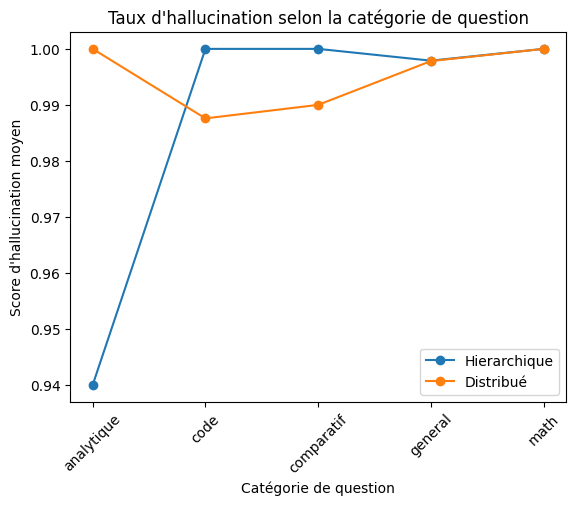

In [8]:
import matplotlib.pyplot as plt

# Moyenne des hallucinations par catégorie
hier_grouped = df_hier.groupby("domaine_detecte")["score_hallucination"].mean()
dist_grouped = df_dist.groupby("domaine_detecte")["score_hallucination"].mean()

# Plot
plt.figure()

plt.plot(hier_grouped.index, hier_grouped.values, marker='o', label="Hierarchique")
plt.plot(dist_grouped.index, dist_grouped.values, marker='o', label="Distribué")

plt.title("Taux d'hallucination selon la catégorie de question")
plt.xlabel("Catégorie de question")
plt.ylabel("Score d'hallucination moyen")
plt.legend()
plt.xticks(rotation=45)

plt.show()

## **Interprétation des résultats**

Les résultats expérimentaux montrent que le taux d’hallucination varie fortement selon le type de question et l’architecture utilisée : l’architecture hiérarchique présente une hallucination quasi nulle sur les questions analytiques et mathématiques, tandis que l’architecture distribuée tend à mieux performer sur les questions de type code mais devient plus instable sur les tâches analytiques, comparatives et générales, où elle présente des taux d’hallucination plus élevés.

Les résultats montrent qu’il n’existe pas d’architecture universellement optimale, mais plutôt un compromis entre stabilité et spécialisation selon le type de tâche.

L’architecture hiérarchique réduit globalement le taux d’hallucination sur les tâches analytiques et mathématiques, tandis que l’architecture distribuée est plus performante sur les tâches de code, mais présente une variabilité plus élevée sur les questions analytiques, comparatives et générales.

Ainsi, le choix de l’architecture dépend directement de la nature de la requête et de l’objectif recherché, notamment la minimisation de l’hallucination ou l’optimisation de la spécialisation.

## **Visualisation des scores d’évaluation des architectures multi-agents**

Cette section présente une analyse comparative des performances des architectures hiérarchique et distribuée à travers plusieurs métriques clés, notamment le score de qualité, le score d’hallucination et le score global, évalués à l’aide d’un LLM juge (meta/llama-3.1-70b-instruct).

Les visualisations permettent d’observer les différences de comportement entre les deux architectures selon les critères de performance et de fiabilité.

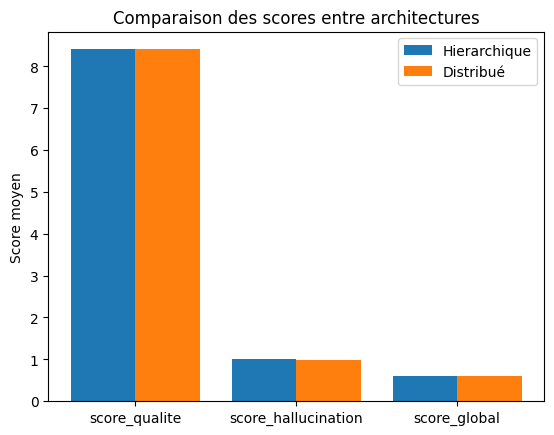

In [9]:
import matplotlib.pyplot as plt

metrics = ["score_qualite", "score_hallucination", "score_global"]

df_hier_mean = df_hier[metrics].mean()
df_dist_mean = df_dist[metrics].mean()

x = range(len(metrics))

plt.figure()

plt.bar([i - 0.2 for i in x], df_hier_mean, width=0.4, label="Hierarchique")
plt.bar([i + 0.2 for i in x], df_dist_mean, width=0.4, label="Distribué")

plt.xticks(x, metrics)
plt.ylabel("Score moyen")
plt.title("Comparaison des scores entre architectures")
plt.legend()

plt.show()

## **Analyse des résultats expérimentaux et interprétation des scores**

Les résultats expérimentaux montrent que le score de qualité moyen est globalement similaire pour les deux architectures, avec une valeur proche de 8.9 sur 10, ce qui indique un niveau de performance élevé et relativement stable pour les deux approches.

Cependant, une différence notable apparaît au niveau du score d’hallucination : l’architecture distribuée présente en moyenne de meilleures performances sur ce critère, ce qui suggère une réduction des erreurs factuelles dans certains contextes. Malgré cela, le score global reste relativement équivalent entre les deux architectures, ce qui indique un équilibre entre les différentes composantes de l’évaluation (temps, tokens, hallucination, outils et qualité).

Le score global est calculé à partir de la formule pondérée suivante :

Score_global = W_time × S_time + W_tokens × S_tokens + W_hallucination × S_hallucination + W_tools × S_tools + W_quality × (Quality_score / 10)

où chaque composante est normalisée afin de permettre une comparaison cohérente entre les différents critères de performance.

Ces résultats suggèrent que, bien que les architectures présentent des comportements différents selon les métriques individuelles, leur performance globale tend à converger, indiquant un compromis entre qualité de réponse, efficacité et stabilité.

## **Comparaison du score d’utilisation des outils entre les architectures**



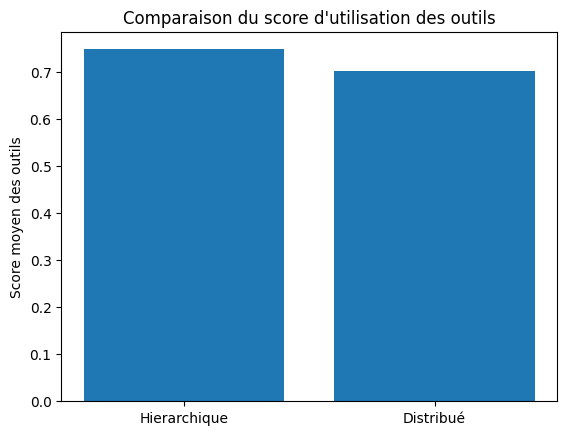

In [10]:
import matplotlib.pyplot as plt

hier_mean = df_hier["score_outils"].mean()
dist_mean = df_dist["score_outils"].mean()

plt.figure()

plt.bar(["Hierarchique", "Distribué"], [hier_mean, dist_mean])

plt.ylabel("Score moyen des outils")
plt.title("Comparaison du score d'utilisation des outils")

plt.show()

## **Interprétation du score d’utilisation des outils**

Les résultats montrent que l’architecture hiérarchique présente en moyenne un score d’utilisation des outils plus élevé que l’architecture distribuée. Cela s’explique par la structure de son pipeline, où chaque requête suit un workflow séquentiel bien défini impliquant systématiquement plusieurs agents spécialisés (Planning, RAG, Tools, Verification et Synthesis), ce qui augmente naturellement la fréquence d’appel aux outils.

À l’inverse, l’architecture distribuée repose sur un EventBus et un mécanisme de routage dynamique où seuls certains agents sont activés selon le contexte de la requête, ce qui entraîne une utilisation plus sélective et donc globalement plus faible des outils dans le flux d’exécution.

## **Construction du dataset final de routage basé sur les performances**

Cette étape consiste à transformer les résultats expérimentaux des architectures hiérarchique et distribuée en un dataset de décision. Pour chaque question commune aux deux systèmes, nous comparons le score global obtenu par chaque architecture, puis nous attribuons une étiquette correspondant à l’architecture la plus performante.

Ainsi, le dataset final contient uniquement les éléments essentiels à la prise de décision : la question initiale, le score global de l’architecture hiérarchique, le score global de l’architecture distribuée, ainsi que la cible indiquant l’architecture optimale.

Cette approche permet de formaliser le problème comme une tâche de classification supervisée visant à apprendre un routeur intelligent capable de sélectionner dynamiquement l’architecture la plus performante selon la requête utilisateur.

In [11]:
import pandas as pd

# df_hier et df_dist doivent déjà être alignés (mêmes question_raw)

# 1. Fusionner les deux datasets sur question_raw
df_merge = pd.merge(
    df_hier[["question_raw", "score_global"]].rename(columns={"score_global": "score_hier"}),
    df_dist[["question_raw", "score_global"]].rename(columns={"score_global": "score_dist"}),
    on="question_raw",
    how="inner"
)

# 2. Créer le label target (meilleure architecture)
df_merge["target"] = df_merge.apply(
    lambda row: "hierarchique" if row["score_hier"] >= row["score_dist"] else "distribue",
    axis=1
)

# 3. Nettoyage final
df_final = df_merge[[
    "question_raw",
    "score_hier",
    "score_dist",
    "target"
]]

# 4. Vérification
print(df_final.head())
print(df_final["target"].value_counts())

                                        question_raw  score_hier  score_dist  \
0  Trouve le 10ème terme de la suite arithmétique...       0.635       0.635   
1                Calcule sin(30°) sans calculatrice.       0.635       0.615   
2                Résous l'équation 5x² + 3x - 2 = 0.       0.615       0.635   
3     Calcule la surface d'une sphère de rayon 5 cm.       0.595       0.595   
4           Convertis 0,75 en fraction irréductible.       0.595       0.615   

         target  
0  hierarchique  
1  hierarchique  
2     distribue  
3  hierarchique  
4     distribue  
target
hierarchique    81
distribue       26
Name: count, dtype: int64


## **Construction du dataset final (question → sortie uniquement)**

Dans cette étape, nous construisons un dataset simplifié destiné à l’apprentissage d’un routeur intelligent entre deux architectures multi-agents. L’objectif est de ne conserver que l’information essentielle pour la prise de décision, à savoir la question initiale et l’architecture la plus performante.

Pour chaque question commune aux deux systèmes, nous comparons les scores globaux de l’architecture hiérarchique et de l’architecture distribuée. L’architecture ayant le score le plus élevé est sélectionnée comme cible.

Le dataset final contient donc uniquement deux colonnes : la question (`question_raw`) et la sortie (`target`), représentant l’architecture optimale à utiliser.

Cette représentation permet de formaliser le problème comme une tâche de classification supervisée visant à prédire dynamiquement la meilleure architecture en fonction de la requête utilisateur.

In [12]:
import pandas as pd

# Assumer que df_hier et df_dist sont déjà alignés (mêmes question_raw)
# 1. Fusion des scores globaux uniquement
df_merge = pd.merge(
    df_hier[["question_raw", "score_global"]].rename(columns={"score_global": "score_hier_global"}),
    df_dist[["question_raw", "score_global"]].rename(columns={"score_global": "score_dist_global"}),
    on="question_raw",
    how="inner"
)

# 2. Création du label (architecture gagnante)
df_merge["target"] = df_merge.apply(
    lambda row: "hierarchique" if row["score_hier_global"] >= row["score_dist_global"] else "distribue",
    axis=1
)

# 3. Dataset final (question + sortie uniquement)
df_final = df_merge[[
    "question_raw",
    "target"
]]

# 4. Affichage
print(df_final.head())
print(df_final["target"].value_counts())

# 5. Sauvegarde optionnelle
df_final.to_csv("dataset_routing_minimal.csv", index=False)

                                        question_raw        target
0  Trouve le 10ème terme de la suite arithmétique...  hierarchique
1                Calcule sin(30°) sans calculatrice.  hierarchique
2                Résous l'équation 5x² + 3x - 2 = 0.     distribue
3     Calcule la surface d'une sphère de rayon 5 cm.  hierarchique
4           Convertis 0,75 en fraction irréductible.     distribue
target
hierarchique    81
distribue       26
Name: count, dtype: int64


**PRÉTRAITEMENT ET PRÉPARATION DES DONNÉES**

In [15]:
# ============================================================================
# BLOC 1 : PRÉPARATION DES DONNÉES (AUCUN ENTRAÎNEMENT)
# ============================================================================
# Ce bloc ne fait que :
# - Nettoyer les textes
# - Extraire des features
# - Encoder la cible
# - Sauvegarder le dataset final prêt pour l'entraînement
# ============================================================================

import pandas as pd
import numpy as np
import re
import string
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("BLOC 1 : PRÉPARATION DES DONNÉES")
print("="*80)

# 1.1 Chargement du dataset brut
print("\n📂 1.1 Chargement des données brutes...")
df = pd.read_csv("dataset_routing_minimal.csv")
print(f"   Shape original: {df.shape}")
print(f"   Colonnes: {df.columns.tolist()}")
print(f"\n   Distribution cible brute:")
print(df['target'].value_counts())

# 1.2 Fonctions de nettoyage et extraction
def clean_text(text):
    """Nettoyage basique du texte"""
    text = str(text).lower()
    text = re.sub(r'\d+', ' ', text)  # chiffres -> espaces
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_features(question):
    """Extraction de features supplémentaires"""
    features = {}

    # Features basiques
    features['len_chars'] = len(question)
    features['len_words'] = len(question.split())
    features['avg_word_len'] = features['len_chars'] / max(features['len_words'], 1)

    # Mots-clés mathématiques
    math_keywords = [
        'sin', 'cos', 'tan', 'cot', 'sec', 'csc',
        'equation', 'inequation', 'egalite',
        'derive', 'integrale', 'limite',
        'suite', 'arithmetique', 'geometrique',
        'fraction', 'decimal', 'pourcentage',
        'rayon', 'diametre', 'perimetre', 'surface', 'volume',
        'triangle', 'carre', 'rectangle', 'cercle',
        'matrice', 'determinant', 'vecteur',
        'log', 'ln', 'exp', 'puissance', 'racine'
    ]
    features['math_keyword_count'] = sum(1 for kw in math_keywords if kw in question.lower())

    # Verbes d'action
    action_verbs = ['calculer', 'trouver', 'resoudre', 'determiner', 'simplifier',
                    'convertir', 'evaluer', 'comparer']
    features['action_verb_count'] = sum(1 for verb in action_verbs if verb in question.lower())

    # Formules mathématiques
    features['has_formula'] = int(any(pattern in question for pattern in ['²', '^', '√', '∑', '∫']))
    features['special_chars_count'] = sum(1 for c in question if c in '²^√∑∫=+-*/')

    # Complexité
    features['has_numbers'] = int(any(c.isdigit() for c in question))

    return features

# 1.3 Application du prétraitement
print("\n🔧 1.2 Application du prétraitement...")

# Nettoyage du texte
df['question_clean'] = df['question_raw'].apply(clean_text)
print("   ✓ Nettoyage du texte effectué")

# Extraction des features
feature_dicts = []
for idx, row in df.iterrows():
    feats = extract_features(row['question_raw'])
    feature_dicts.append(feats)

df_features = pd.DataFrame(feature_dicts)
for col in df_features.columns:
    df[col] = df_features[col].values

print(f"   ✓ {len(df_features.columns)} features extraites")
print(f"   Features: {list(df_features.columns)}")

# 1.4 Encodage de la cible
print("\n🏷️ 1.3 Encodage de la cible...")
le = LabelEncoder()
df['target_enc'] = le.fit_transform(df['target'])
print(f"   Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"   → hierarchique = {le.transform(['hierarchique'])[0]}")
print(f"   → distribue = {le.transform(['distribue'])[0]}")

# 1.5 Vérification finale
print("\n✅ 1.4 Vérification du dataset préparé...")
print(f"   Shape final: {df.shape}")
print(f"   Colonnes disponibles: {df.columns.tolist()}")
print(f"\n   Distribution cible encodée:")
print(df['target_enc'].value_counts())

# 1.6 Sauvegarde du dataset prêt
print("\n💾 1.5 Sauvegarde du dataset prêt...")

# Sauvegarde du CSV prêt pour l'entraînement
df.to_csv("dataset_ready_for_training.csv", index=False)
print("   ✓ Dataset sauvegardé: 'dataset_ready_for_training.csv'")

# Sauvegarde des encodeurs pour utilisation future
preprocessing_artifacts = {
    'label_encoder': le,
    'feature_columns': df_features.columns.tolist(),
    'target_mapping': dict(zip(le.classes_, le.transform(le.classes_)))
}
joblib.dump(preprocessing_artifacts, "preprocessing_artifacts.pkl")
print("   ✓ Artéfacts de préprocessing sauvegardés: 'preprocessing_artifacts.pkl'")

# 1.7 Affichage d'échantillons préparés
print("\n📊 1.6 Échantillon du dataset préparé:")
print("="*80)
print(df[['question_raw', 'question_clean', 'target', 'target_enc', 'len_chars',
          'len_words', 'math_keyword_count', 'action_verb_count']].head(10))
print("="*80)

print("\n📈 Statistiques des features numériques:")
print(df[df_features.columns.tolist()].describe())

print("\n" + "="*80)
print("FIN DU BLOC 1 - DATASET PRÊT POUR L'ENTRAÎNEMENT")
print(f"Fichiers générés:")
print("  - dataset_ready_for_training.csv")
print("  - preprocessing_artifacts.pkl")
print("="*80)

BLOC 1 : PRÉPARATION DES DONNÉES

📂 1.1 Chargement des données brutes...
   Shape original: (107, 2)
   Colonnes: ['question_raw', 'target']

   Distribution cible brute:
target
hierarchique    81
distribue       26
Name: count, dtype: int64

🔧 1.2 Application du prétraitement...
   ✓ Nettoyage du texte effectué
   ✓ 8 features extraites
   Features: ['len_chars', 'len_words', 'avg_word_len', 'math_keyword_count', 'action_verb_count', 'has_formula', 'special_chars_count', 'has_numbers']

🏷️ 1.3 Encodage de la cible...
   Mapping: {'distribue': np.int64(0), 'hierarchique': np.int64(1)}
   → hierarchique = 1
   → distribue = 0

✅ 1.4 Vérification du dataset préparé...
   Shape final: (107, 12)
   Colonnes disponibles: ['question_raw', 'target', 'question_clean', 'len_chars', 'len_words', 'avg_word_len', 'math_keyword_count', 'action_verb_count', 'has_formula', 'special_chars_count', 'has_numbers', 'target_enc']

   Distribution cible encodée:
target_enc
1    81
0    26
Name: count, dtype

**ENTRAÎNEMENT, OPTIMISATION ET ÉVALUATION**

In [22]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00


BLOC 2 : ANTI-OVERFITTING + GESTION CLASSES DÉSÉQUILIBRÉES

📂 2.1 Chargement...
   Distribution: {'hierarchique': 81, 'distribue': 26}

🔧 2.2 Préparation des features...
   X shape: (107, 158)

✂️ 2.3 Split...
   Train: 80 | Test: 27
   Train distribue: 19 | hierarchique: 61

⚖️ 2.4 SMOTE pour équilibrer...
   Après SMOTE: 122 samples
   distribue: 61 | hierarchique: 61

🚀 2.5 Entraînement avec régularisation...

🔍 Random Forest
✅ Train acc: 0.863 | Test acc: 0.741 (Δ: 0.122)
✅ Train f1:  0.768  | Test f1:  0.533  (Δ: 0.235)
✅ ROC-AUC: 0.764 | CV f1: 0.475 (+/-0.126)
✅ Overfitting: ⚠️ OUI

🔍 XGBoost
✅ Train acc: 0.812 | Test acc: 0.667 (Δ: 0.146)
✅ Train f1:  0.700  | Test f1:  0.400  (Δ: 0.300)
✅ ROC-AUC: 0.643 | CV f1: 0.486 (+/-0.105)
✅ Overfitting: ⚠️ OUI

🔍 CatBoost
✅ Train acc: 0.850 | Test acc: 0.815 (Δ: 0.035)
✅ Train f1:  0.776  | Test f1:  0.667  (Δ: 0.109)
✅ ROC-AUC: 0.686 | CV f1: 0.455 (+/-0.106)
✅ Overfitting: ✅ NON

🔍 Logistic Regression
✅ Train acc: 0.637 | Test acc: 0.

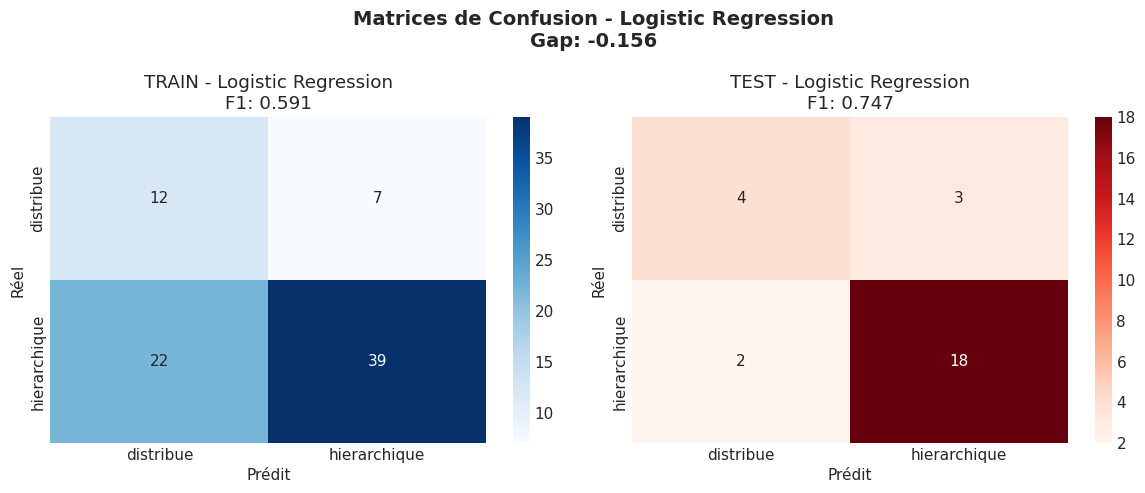


2.8 CLASSIFICATION REPORT DÉTAILLÉ

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

   distribue       0.67      0.57      0.62         7
hierarchique       0.86      0.90      0.88        20

    accuracy                           0.81        27
   macro avg       0.76      0.74      0.75        27
weighted avg       0.81      0.81      0.81        27


2.9 ANALYSE DES ERREURS

📊 Erreurs: 5/27 (18.5%)

🔍 Questions mal classées:

  1. Question: Résous l'équation 5x² + 3x - 2 = 0....
     Vrai: hierarchique | Prédit: distribue

  2. Question: Calcule le logarithme en base 10 de 1000....
     Vrai: distribue | Prédit: hierarchique

  3. Question: Comment fonctionne une boucle for en Python ?...
     Vrai: distribue | Prédit: hierarchique

  4. Question: Écris une fonction Python qui vérifie si un nombre est premier....
     Vrai: distribue | Prédit: hierarchique

  5. Question: Quelle est la différence entre une fonction et une méthode

In [28]:
# ============================================================================
# BLOC 2 : ANTI-OVERFITTING + GESTION CLASSES DÉSÉQUILIBRÉES
# ============================================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
from catboost import CatBoostClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("BLOC 2 : ANTI-OVERFITTING + GESTION CLASSES DÉSÉQUILIBRÉES")
print("="*80)

# 2.1 Chargement
print("\n📂 2.1 Chargement...")
df = pd.read_csv("dataset_ready_for_training.csv")
preprocessing_artifacts = joblib.load("preprocessing_artifacts.pkl")
le = preprocessing_artifacts['label_encoder']
feature_cols = preprocessing_artifacts['feature_columns']
print(f"   Distribution: {df['target'].value_counts().to_dict()}")

# 2.2 Préparation
print("\n🔧 2.2 Préparation des features...")
tfidf = TfidfVectorizer(max_features=150, ngram_range=(1, 2), min_df=2, max_df=0.9)
X_tfidf = tfidf.fit_transform(df['question_clean']).toarray()

X_extra = df[feature_cols].values
scaler = StandardScaler()
X_extra_scaled = scaler.fit_transform(X_extra)

X = np.hstack([X_tfidf, X_extra_scaled])
y = df['target_enc'].values
print(f"   X shape: {X.shape}")

# 2.3 Split STRATIFIÉ
print("\n✂️ 2.3 Split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"   Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"   Train distribue: {np.sum(y_train==0)} | hierarchique: {np.sum(y_train==1)}")

# 2.4 SMOTE pour équilibrer les classes
print("\n⚖️ 2.4 SMOTE pour équilibrer...")
k_neighbors = min(3, np.sum(y_train==0) - 1)
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"   Après SMOTE: {X_train_balanced.shape[0]} samples")
print(f"   distribue: {np.sum(y_train_balanced==0)} | hierarchique: {np.sum(y_train_balanced==1)}")

# 2.5 K-Fold STRATIFIÉ
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# MODÈLES AVEC RÉGULARISATION FORTE
# ============================================================================
# NOTE : early_stopping_rounds retiré de XGBoost — incompatible avec GridSearchCV
# car il nécessite un eval_set explicite dans .fit(). La cross-validation + les
# hyperparamètres de régularisation (reg_alpha, reg_lambda, gamma) jouent ce rôle.

models_config = {
    'Random Forest': {
        'model': RandomForestClassifier(
            random_state=42,
            class_weight='balanced',
            n_jobs=-1,
            oob_score=True
        ),
        'params': {
            'n_estimators': [50, 80],
            'max_depth': [3, 5, 7],
            'min_samples_split': [5, 10, 15],
            'min_samples_leaf': [2, 4, 6],
            'max_features': ['sqrt', 0.5]
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            # early_stopping_rounds retiré : incompatible avec GridSearchCV/Pipeline
        ),
        'params': {
            'n_estimators': [50, 80],
            'max_depth': [2, 3, 4],
            'learning_rate': [0.01, 0.05],
            'subsample': [0.6, 0.8],
            'colsample_bytree': [0.6, 0.8],
            'reg_alpha': [0.1, 1, 10],
            'reg_lambda': [0.1, 1, 10],
            'gamma': [0, 1, 5]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(
            random_state=42,
            verbose=0,
            auto_class_weights='Balanced'
        ),
        'params': {
            'iterations': [50, 80],
            'depth': [3, 4, 5],
            'learning_rate': [0.01, 0.05],
            'l2_leaf_reg': [3, 5, 10],
            'bagging_temperature': [0.5, 1],
            'random_strength': [1, 2]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(
            random_state=42,
            class_weight='balanced',
            max_iter=1000
        ),
        'params': {
            'C': [0.01, 0.1, 1],
            'penalty': ['l2'],
            'solver': ['liblinear']
        }
    }
}

# ============================================================================
# ENTRAÎNEMENT AVEC VALIDATION CROISÉE
# ============================================================================
print("\n🚀 2.5 Entraînement avec régularisation...")
print("="*80)

best_models = {}
results = []
train_histories = {}

for model_name, config in models_config.items():
    print(f"\n{'='*50}")
    print(f"🔍 {model_name}")
    print(f"{'='*50}")

    # Pipeline avec SMOTE intégré pour GridSearch
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)),
        ('clf', config['model'])
    ])

    # Préfixe clf__ ajouté automatiquement
    param_grid = {'clf__' + k: v for k, v in config['params'].items()}

    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=kfold,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)
    best_models[model_name] = grid.best_estimator_

    # Prédictions
    y_train_pred = grid.best_estimator_.predict(X_train)
    y_test_pred  = grid.best_estimator_.predict(X_test)
    y_test_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

    # Métriques
    train_acc = np.mean(y_train == y_train_pred)
    test_acc  = np.mean(y_test  == y_test_pred)
    train_f1  = f1_score(y_train, y_train_pred, average='macro')
    test_f1   = f1_score(y_test,  y_test_pred,  average='macro')
    roc_auc   = roc_auc_score(y_test, y_test_proba)

    cv_scores = cross_val_score(
        grid.best_estimator_, X_train, y_train, cv=kfold, scoring='f1_macro'
    )

    results.append({
        'model':    model_name,
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'train_f1':  train_f1,
        'test_f1':   test_f1,
        'roc_auc':   roc_auc,
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std()
    })

    train_histories[model_name] = {
        'y_train_pred': y_train_pred,
        'y_test_pred':  y_test_pred,
        'y_test_proba': y_test_proba,
        'params':       grid.best_params_
    }

    print(f"✅ Train acc: {train_acc:.3f} | Test acc: {test_acc:.3f} (Δ: {train_acc-test_acc:.3f})")
    print(f"✅ Train f1:  {train_f1:.3f}  | Test f1:  {test_f1:.3f}  (Δ: {train_f1-test_f1:.3f})")
    print(f"✅ ROC-AUC: {roc_auc:.3f} | CV f1: {cv_scores.mean():.3f} (+/-{cv_scores.std():.3f})")
    print(f"✅ Overfitting: {'⚠️ OUI' if train_acc - test_acc > 0.1 else '✅ NON'}")

# ============================================================================
# COMPARAISON
# ============================================================================
print("\n" + "="*80)
print("2.6 COMPARAISON FINALE")
print("="*80)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

results_df['overfit_gap'] = results_df['train_f1'] - results_df['test_f1']
best_model_name = results_df.loc[results_df['test_f1'].idxmax(), 'model']
best_model = best_models[best_model_name]

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   Test F1: {results_df.loc[results_df['model']==best_model_name, 'test_f1'].values[0]:.4f}")
print(f"   Overfitting gap: {results_df.loc[results_df['model']==best_model_name, 'overfit_gap'].values[0]:.4f}")

# ============================================================================
# MATRICES DE CONFUSION DÉTAILLÉES
# ============================================================================
print("\n" + "="*80)
print("2.7 MATRICES DE CONFUSION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, train_histories[best_model_name]['y_train_pred'])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['distribue', 'hierarchique'],
            yticklabels=['distribue', 'hierarchique'])
axes[0].set_title(
    f'TRAIN - {best_model_name}\n'
    f'F1: {results_df.loc[results_df["model"]==best_model_name, "train_f1"].values[0]:.3f}'
)
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')

cm_test = confusion_matrix(y_test, train_histories[best_model_name]['y_test_pred'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['distribue', 'hierarchique'],
            yticklabels=['distribue', 'hierarchique'])
axes[1].set_title(
    f'TEST - {best_model_name}\n'
    f'F1: {results_df.loc[results_df["model"]==best_model_name, "test_f1"].values[0]:.3f}'
)
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

gap = (results_df.loc[results_df['model']==best_model_name, 'train_f1'].values[0]
       - results_df.loc[results_df['model']==best_model_name, 'test_f1'].values[0])
plt.suptitle(
    f'Matrices de Confusion - {best_model_name}\nGap: {gap:.3f}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrices_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# CLASSIFICATION REPORT DÉTAILLÉ
# ============================================================================
print("\n" + "="*80)
print("2.8 CLASSIFICATION REPORT DÉTAILLÉ")
print("="*80)

y_test_pred = train_histories[best_model_name]['y_test_pred']
print(f"\n{best_model_name} - Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['distribue', 'hierarchique']))

# ============================================================================
# ANALYSE DES ERREURS
# ============================================================================
print("\n" + "="*80)
print("2.9 ANALYSE DES ERREURS")
print("="*80)

errors = y_test != y_test_pred
if np.any(errors):
    print(f"\n📊 Erreurs: {np.sum(errors)}/{len(y_test)} ({np.sum(errors)/len(y_test)*100:.1f}%)")
    error_indices = [i for i in range(len(y_test)) if errors[i]]
    print("\n🔍 Questions mal classées:")
    for i, idx in enumerate(error_indices[:10]):
        true_label = le.inverse_transform([y_test[idx]])[0]
        pred_label = le.inverse_transform([y_test_pred[idx]])[0]
        original_question = df.iloc[idx]['question_raw']
        print(f"\n  {i+1}. Question: {original_question[:80]}...")
        print(f"     Vrai: {true_label} | Prédit: {pred_label}")
else:
    print("\n✅ Pas d'erreur sur le test set!")

# ============================================================================
# SAUVEGARDE
# ============================================================================
print("\n" + "="*80)
print("2.10 SAUVEGARDE")
print("="*80)

final_pipeline = {
    'model':           best_model.named_steps['clf'],
    'model_name':      best_model_name,
    'tfidf_vectorizer': tfidf,
    'feature_scaler':  scaler,
    'label_encoder':   le,
    'feature_columns': feature_cols,
    'results':         results_df,
    'best_params':     train_histories[best_model_name]['params']
}

joblib.dump(final_pipeline, "final_router_pipeline.pkl")
print("✅ Modèle sauvegardé: final_router_pipeline.pkl")

# ============================================================================
# TEST FINAL
# ============================================================================
print("\n" + "="*80)
print("2.11 TEST SUR EXEMPLES")
print("="*80)

def predict_question(question, pipeline):
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'\d+', ' ', text)
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def extract_features(question):
        features = {}
        features['len_chars']    = len(question)
        features['len_words']    = len(question.split())
        features['avg_word_len'] = features['len_chars'] / max(features['len_words'], 1)
        math_keywords = ['sin', 'cos', 'tan', 'equation', 'derive', 'integrale', 'suite', 'fraction']
        features['math_keyword_count'] = sum(1 for kw in math_keywords if kw in question.lower())
        action_verbs = ['calculer', 'trouver', 'resoudre', 'determiner', 'simplifier']
        features['action_verb_count']  = sum(1 for v in action_verbs if v in question.lower())
        features['has_formula']        = int(any(c in question for c in ['²', '^', '√']))
        features['special_chars_count'] = sum(1 for c in question if c in '²^√=+-*/')
        features['has_numbers']        = int(any(c.isdigit() for c in question))
        return features

    question_clean = clean_text(question)
    tfidf_vec  = pipeline['tfidf_vectorizer'].transform([question_clean]).toarray()
    feats      = extract_features(question)
    extra_vec  = np.array([[feats[col] for col in pipeline['feature_columns']]])
    extra_scaled = pipeline['feature_scaler'].transform(extra_vec)
    X_new = np.hstack([tfidf_vec, extra_scaled])

    pred_enc  = pipeline['model'].predict(X_new)[0]
    pred_proba = pipeline['model'].predict_proba(X_new)[0]
    arch = pipeline['label_encoder'].inverse_transform([pred_enc])[0]
    return arch, max(pred_proba), pred_proba

test_questions = [
    "Résous l'équation 5x² + 3x - 2 = 0",
    "Trouve le 10ème terme de la suite arithmétique",
    "Calcule sin(30°) sans calculatrice",
    "Convertis 0,75 en fraction",
    "Calcule la surface d'un cercle de rayon 5"
]

print(f"\n📝 Tests avec {best_model_name} (anti-overfitting):")
for q in test_questions:
    arch, conf, proba = predict_question(q, final_pipeline)
    print(f"\nQuestion: {q}")
    print(f"  → Architecture: {arch.upper()} (confiance: {conf:.3f})")
    print(f"  → Proba: hierarchique={proba[1]:.3f}, distribue={proba[0]:.3f}")

print("\n" + "="*80)
print("✅ ANTI-OVERFITTING ACTIVÉ")
print("   - SMOTE pour équilibrer")
print("   - Régularisation renforcée")
print("   - Profondeur limitée")
print("   - Cross-validation stricte")
print("="*80)

In [29]:
import joblib

# Charger le modèle
pipeline = joblib.load("/content/final_router_pipeline.pkl")

# Vérifier que c'est bien Logistic Regression
print(f"📦 Modèle chargé: {pipeline['model_name']}")
print(f"📊 Test F1-score: {pipeline['results'].loc[pipeline['results']['model']=='Logistic Regression', 'test_f1'].values[0]:.4f}")
print(f"🎯 Accuracy test: {pipeline['results'].loc[pipeline['results']['model']=='Logistic Regression', 'test_acc'].values[0]:.4f}")

# Test rapide
question = "Résous l'équation 5x² + 3x - 2 = 0"
# (utilisez votre fonction predict_question)

📦 Modèle chargé: Logistic Regression
📊 Test F1-score: 0.7467
🎯 Accuracy test: 0.8148
